# ***Perceptron***

**Integrantes do grupo 3:**

Anysabele de Paula Barbosa Santos

Maria Clara Pereira Gonçalves

Millena Ferreira Marçal das Neves

**Objetivo do projeto:**
Este projeto tem como objetivo identificar e demonstrar limitações do Perceptron através da experimentação de casos em que o modelo é estressado ou tem seus parâmetros alterados.

Os cenários em que o Perceptron foi testado são:
1. Dataset com atributos não linearmente separáveis;
2. Demonstração do Perceptron instável;
3. Presença de outliers no dataset.

In [ ]:
# Importação de bibliotecas
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_circles
from sklearn.datasets import make_moons

# `Demostração 1: Perceptron funcionando bem`
- Criação de um cenário perfeito para o perceptron: duas classes linearmente separáveis e sem ruídos.

In [ ]:
iris = load_iris()

In [ ]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df.shape

(150, 4)

In [ ]:
df.head(1)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2


In [ ]:
print("Classes do dataset Iris:")
for i, classe in enumerate(iris.target_names):
    print(f"{i} -> {classe}")

Classes do dataset Iris:
0 -> setosa
1 -> versicolor
2 -> virginica


O Dataset iris original possui 4 atrbutos, iremos remover dois para usar no nosso modelo.

In [ ]:
# seleção de apenas 2 atributos
X = iris.data[:, :2]
# classes
y = iris.target

# removendo a classe 2 (virginica)
mask = y != 2

X = X[mask]
y = y[mask]

print(X.shape, y.shape)

(100, 2) (100,)


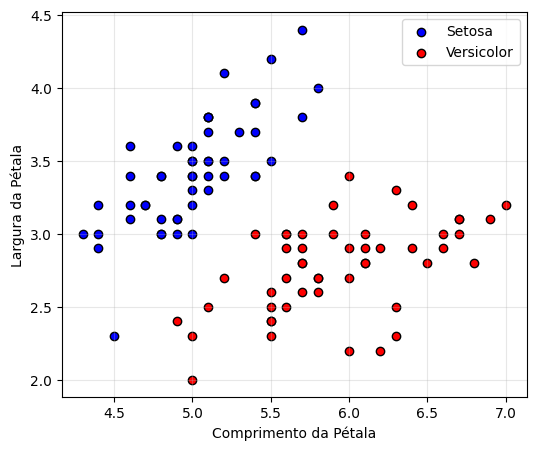

In [ ]:
plt.figure(figsize=(6,5))


plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    color='blue',
    edgecolors='k',
    label='Setosa'
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    color='red',
    edgecolors='k',
    label='Versicolor'
)

plt.xlabel("Comprimento da Pétala")
plt.ylabel("Largura da Pétala")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

Implementação do Perceptron usando diferentes parâmetros da biblioteca Scikit Learn. Queremos destacar o uso de: embaralhamento dos dados a cada época para evitar possíveis vieses, número máximo de interações e uso do intercepto para tornar a fronteira de decisão mais flexível.

In [ ]:
model = Perceptron(
    penalty=None,            # Tipo de regularização (None, L1, L2 ou ElasticNet)
    alpha=0.0001,            # Intensidade da regularização
    l1_ratio=0.15,           # Proporção entre L1 e L2 no ElasticNet
    fit_intercept=True,      # Adiciona o termo de viés/intercepto
    max_iter=1000,           # Número máximo de épocas de treinamento
    tol=0.001,               # Critério mínimo de melhora para continuar treinando
    shuffle=True,            # Embaralha os dados a cada época
    verbose=0,               # Exibe logs do treinamento se > 0
    eta0=1.0,                # Taxa de aprendizagem
    n_jobs=None,             # Número de núcleos utilizados
    random_state=42,         # Seed para reprodutibilidade
    early_stopping=False,    # Interrompe o treino antecipadamente se não houver melhora
    validation_fraction=0.1, # Fração usada para validação no early stopping
    n_iter_no_change=5,      # Tolerância de épocas sem melhora
    class_weight=None,       # Pesos para classes desbalanceadas
    warm_start=False         # Reaproveita pesos do treinamento anterior
)
# Também é possível definir essas configurações como um dicionário e só aproveitar a estrutura, sem repetir tudo:
# configuracao = {"Penalty" : None, "alpha" : 0.0001, ... }
# model = Perceptron(**configuracao)

In [ ]:
# Treinamento
model.fit(X_train, y_train)

# Predição
y_pred = model.predict(X_test)


Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.8824    1.0000    0.9375        15
           1     1.0000    0.8667    0.9286        15

    accuracy                         0.9333        30
   macro avg     0.9412    0.9333    0.9330        30
weighted avg     0.9412    0.9333    0.9330        30



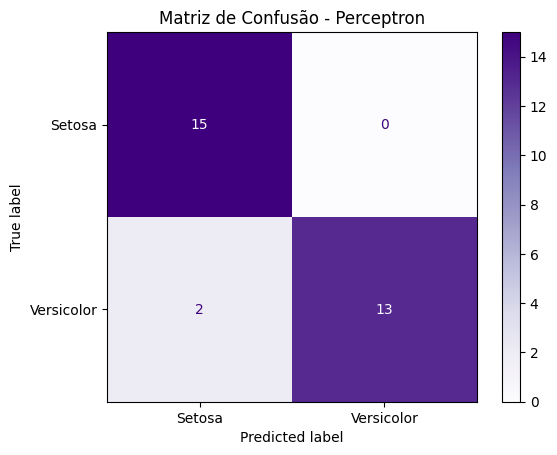

In [ ]:
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

# Plot da matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Setosa", "Versicolor"])
disp.plot(cmap='Purples')
plt.title("Matriz de Confusão - Perceptron")
plt.show()

In [ ]:
# Função auxiliar para visualização
def plot_decision_boundary (X, y, model, title):
  h= .02
  x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
  y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

  Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
  Z = Z.reshape(xx.shape)

  plt.figure(figsize=(8, 5))
  plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FF9999', '#9999FF']))
  plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=ListedColormap(['#FF0000', '#0000FF']))
  plt.title(title)
  plt.xlabel("Atributo 1")
  plt.ylabel("Atributo 2")
  plt.show()

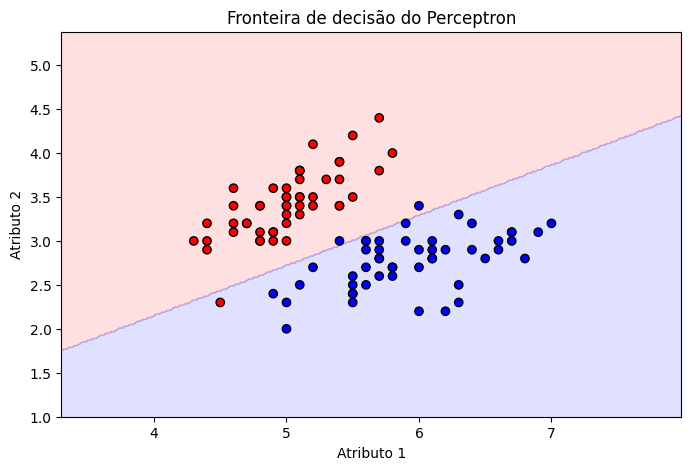

In [ ]:
# Plot de visualização
plot_decision_boundary(X, y, model, "Fronteira de decisão do Perceptron")

***Explicação***

O Perceptron obteve um desempenho muito bom, com acurácia de 93,33% e boas métricas de precisão, recall e F1 para ambas as classes, onde o modelo errou apenas 2 das 30 amostras (falsos negativos para Versicolor).

Analisando a fronteira de decisão, percebe-se que o Perceptron aprendeu uma reta linear que separa perfeitamente as duas espécies. Os pontos azuis (Setosa) ficam quase todos de um lado da reta, e os vermelhos (Versicolor) do outro, com apenas um de cada ocupando o espaço errado. Isso confirma que os dados são linearmente separáveis e sem ruído, condição ideal para o funcionamento do algoritmo.

O resultado demonstra como o Perceptron é eficaz nesse cenário perfeito. Agora, vamos testar suas limitações em situações mais realistas.



Referências:
* https://machinelearningmastery.com/perceptron-algorithm-for-classification-in-python/
* https://medium.com/@alef.mattias/criando-um-perceptron-do-zero-com-python-f23bba2375bf
* https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html

# `Teste 2: Atributos Não Linearmente Separáveis.`

O Perceptron é um classificador linear, ou seja, ele tenta separar as classes utilizando apenas uma reta. No conjunto de dados *make_moons*, as classes possuem um formato curvo, tornando o problema não linearmente separável. Dessa forma, o modelo não consegue encontrar uma reta capaz de separar os dados corretamente todos os pontos. Esse teste demonstra uma das principais limitações do perceptron tradicional, que é a sua dificuldade em resolver problemas não lineares.

# Teste 2.1: Atributos Não Linearmente Separáveis



In [ ]:
X_moons, y_moons = make_moons(
    n_samples=200,
    noise=0.15,
    random_state=42)

In [ ]:
# Treinamento do modelo
model_moons = Perceptron(max_iter=1000, random_state=42)
model_moons.fit(X_moons, y_moons);

**Visualização da Falha**

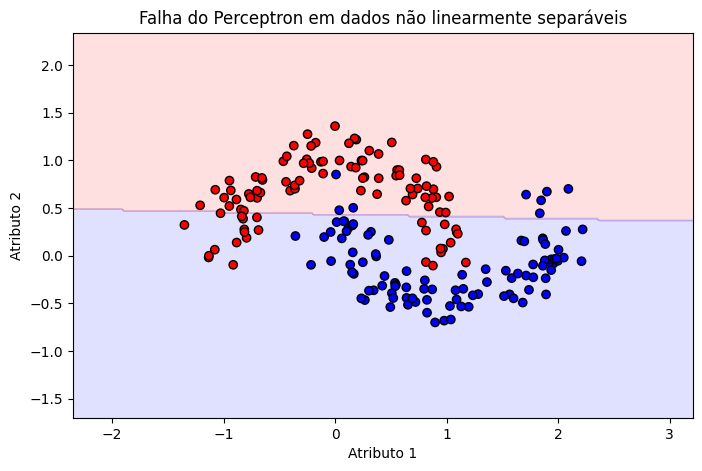

In [ ]:
# Plot de visualização
plot_decision_boundary(
    X_moons,
    y_moons,
    model_moons,
    "Falha do Perceptron em dados não linearmente separáveis")

In [ ]:
acc_moons = model_moons.score(X_moons, y_moons)
print(f"Acurácia: {acc_moons*100:.2f}%")

Acurácia: 82.50%


A acurácia obtida foi de 82.50%, indicando que o modelo não conseguiu separar corretamente todos os dados. Isso acontece porque o Perceptron é um classificador linear e o conjunto make_moons possui uma distribuição não linear. Assim, mesmo com treinamento, o algoritmo não consegue encontrar uma única reta capaz de separar perfeitamente as duas classes.

#Teste 2.2: Atributos Não Linearmente Separáveis

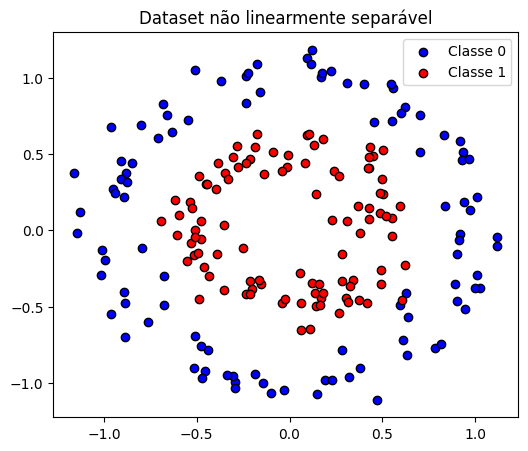

In [ ]:
X_nl, y_nl = make_circles(n_samples=200, noise=0.1, factor=0.5, random_state=42)

plt.figure(figsize=(6,5))
plt.scatter(X_nl[y_nl == 0, 0], X_nl[y_nl == 0, 1], color='blue', edgecolors='k', label='Classe 0')
plt.scatter(X_nl[y_nl == 1, 0], X_nl[y_nl == 1, 1], color='red', edgecolors='k', label='Classe 1')
plt.title("Dataset não linearmente separável")
plt.legend()
plt.show()

**Treinando o perceptron neste cenário**

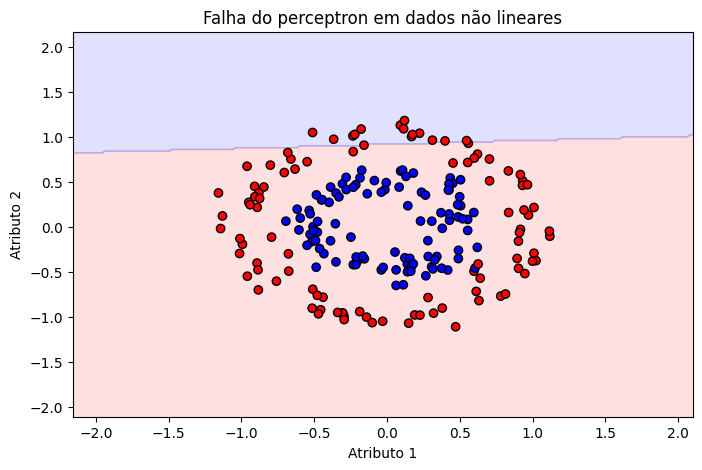

Acurácia no problema não linear: 43.00%


In [ ]:
modelo_nl = Perceptron(random_state=42)
modelo_nl.fit(X_nl, y_nl)

plot_decision_boundary(X_nl, y_nl, modelo_nl, "Falha do perceptron em dados não lineares")

y_pred_nl = modelo_nl.predict(X_nl)
print("Acurácia no problema não linear: {:.2f}%".format(accuracy_score(y_nl, y_pred_nl) * 100))

No gráfico, os dados formam círculos concêntricos, então o problema não pode ser separado por uma linha reta. Como o Perceptron clássico só consegue criar separações lineares, ele acaba “cortando” os dados no meio e não consegue aprender o padrão corretamente.

Por isso, a acurácia fica perto de 50%, praticamente como um chute aleatório em um problema com duas classes. Isso mostra a principal limitação do Perceptron: ele não consegue resolver problemas não-lineares, sendo necessário usar modelos mais avançados.


# `Teste 3: Instabilidade.`

O Perceptron é um modelo simples que inspirou modelos de Inteligência Artificial mais complexos. Por simples, considere que a distinção de classes feita utiliza uma reta como limiar de separação. No entanto, podem existir várias retas que separam de forma satisfatória um conjunto de dados em duas classes. Uma das limitações do Perceptron é justamente essa: encontrar qual a melhor reta resolve um problema de classificação. Devido à sua natureza simples, a escolha final do modelo é a primeira que separa de forma suficiente os pontos, isto é, a fronteira de decisão traçada pode beirar os limites de uma classe.

A fim de testar essa instabilidade, um comparativo com outro modelo será utilizado como referencial, sem alterações no dataset. O Support Vector Machine é o modelo escolhido para fazer esse comparativo, pois seu objetivo é traçar uma curva (reta) que consiga separar as classes suficientemente bem com uma margem de distância entre a fronteira e as instâncias mais próximas.

# Teste 3.1: Instabilidade
Comparativo entre fronteiras de decisão do Percetron e do Support Vector Machine

In [ ]:
# Função auxiliar criação da fronteira de decisão gerada pelos modelos
def plot_decision_boundary(clf, X, color, label, linestyle='-'):
    w = clf.coef_[0] if hasattr(clf, 'coef_') else clf.dual_coef_ @ clf.support_vectors_
    b = clf.intercept_[0]

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x_points = np.linspace(x_min, x_max, 10)
    y_points = -(w[0] / w[1]) * x_points - (b / w[1])

    plt.plot(x_points, y_points, color=color, linestyle=linestyle, label=label, linewidth=2)

    # Para o SVM é importante plotar as margens também, não só a fronteira
    if isinstance(clf, SVC):
        margin = 1 / np.sqrt(np.sum(clf.coef_ ** 2))
        plt.plot(x_points, y_points + margin, color=color, linestyle='--', alpha=0.3)
        plt.plot(x_points, y_points - margin, color=color, linestyle='--', alpha=0.3)

In [ ]:
# Função auxiliar de plotagem da fronteira
# É a mesma lógica da visualização do modelo original no início do notebook
# Função auxiliar de plotagem da fronteira
def comparar_perceptron(modelos, X, y, modelo_fundo, titulo="Fronteira de Decisão"):
    plt.figure(figsize=(7, 6))

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Referencial de área por classe
    Z = modelo_fundo.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')

    # Classe Setosa
    plt.scatter(
        X[y == 0, 0],
        X[y == 0, 1],
        color='blue',
        edgecolors='k',
        label='Setosa'
    )

    # Classe Versicolor
    plt.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        color='red',
        edgecolors='k',
        label='Versicolor'
    )

    for model, cor, label in modelos:
        plot_decision_boundary(model, X, cor, label)

    plt.title(titulo)
    plt.xlabel("Comprimento da Pétala")
    plt.ylabel("Largura da Pétala")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

In [ ]:
# Treinamento do Support Vector Machine com os mesmos dados
from sklearn.svm import SVC

# Como o foco é só comparativo, o SVM não terá seus parâmetros muito personalizados
model_svm = SVC(kernel='linear', C=100)
model_svm.fit(X_train, y_train)

SVC(C=100, kernel='linear')

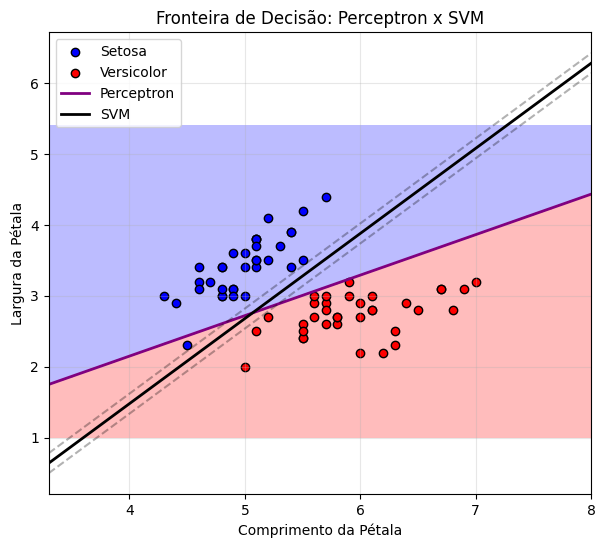

In [ ]:
# Visualização
# Plotando as fronteiras de ambos modelos
modelos1 = [(model, 'purple', 'Perceptron'), (model_svm, 'black', 'SVM')]
comparar_perceptron(modelos1, X_train, y_train, model, titulo="Fronteira de Decisão: Perceptron x SVM")

Observando o gráfico, é visível a diferença entre as fronteiras de decisão, sendo que a fronteira gerada pelo SVM distingue melhor as classes. Isso ocorre pelo seu conceito ser encontrar uma reta que melhor cumpre o papel de classificação, visando ter a máxima margem entre instâncias do conjunto de treino e evitar criar fronteiras que acentuem o papel conflitante de regiões de borda. Nesse processo, o modelo treina repetidas vezes até achar essa distância máxima, o que é justamente o ponto fraco do Perceptron, que para seu treinamento ao achar uma fronteira boa, sem ser necessariamente a melhor possível.
Vale ressaltar que o parâmetro de early_stopping do Perceptron estava desativado e o número de épocas é significativo (1000).

Por outro lado, a instabilidade do Perceptron pode referenciar ao seu desempenho dependente da ordem em que os dados aparecem no conjunto de treino. Quando as instâncias são recebidas em momentos diferentes, devido à característica do Perceptron de parar o treinamento ao achar uma solução boa, diferentes fronteiras de decisão podem ser criadas. Isso será demonstrado em dois experimentos: sem shuffle nas épocas (o modelo anterior estava com essa instrução ativada) e o modelo com mesmos parâmetros, mas com o conjunto de treinamento embaralhado.

# Teste 3.2: Instabilidade
Parâmetro de shuffle para cada época desativado.


In [ ]:
# Definição da variação do modelo
model_no_shuffle = Perceptron(
    shuffle=False,                # Justamente o shuffle desativado
    random_state=42 )             # Uso da mesma seed para todos os experimentos

# Os demais parâmetros permanecem inalterados,
# são da configuração padrão ao importar a biblioteca do Perceptron

# Treinamento
model_no_shuffle.fit(X_train, y_train)

Perceptron(random_state=42, shuffle=False)

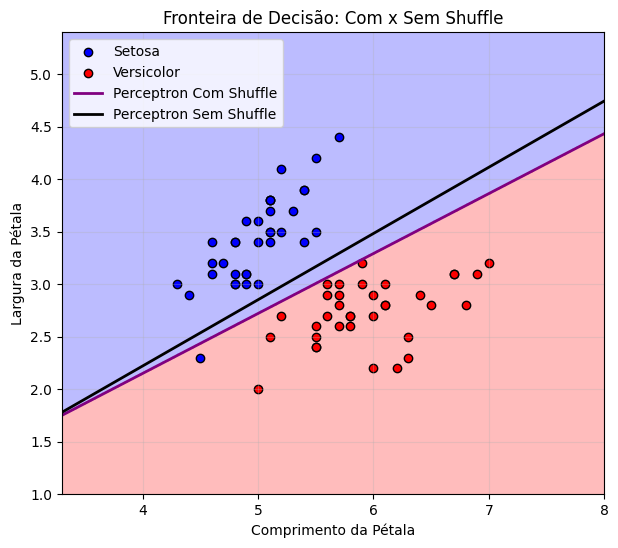

In [ ]:
# Visualização
modelos2 = [(model, 'purple', 'Perceptron Com Shuffle'), (model_no_shuffle, 'black', 'Perceptron Sem Shuffle')]
comparar_perceptron(modelos2, X_train, y_train, model, titulo="Fronteira de Decisão: Com x Sem Shuffle")


Relatório de Classificação:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        15
           1     1.0000    1.0000    1.0000        15

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30



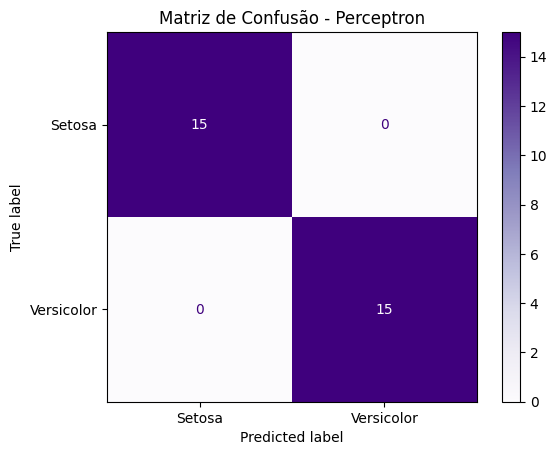

In [ ]:
y_pred_no_shuffle = model_no_shuffle.predict(X_test)
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_no_shuffle, digits=4))

cm = confusion_matrix(y_test, y_pred_no_shuffle)

# Plot da matriz de confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Setosa", "Versicolor"])
disp.plot(cmap='Purples')
plt.title("Matriz de Confusão - Perceptron")
plt.show()

Esse experimento mostra exatamente essa dependência da ordem das instâncias, sendo que, nesse exemplo, o modelo sem shuffle apresentou fronteira de decisão mais coerente com os dados. Além disso, obteve desempenho perfeito ao testar o conjunto de testes, o mesmo ao qual o modelo "original" foi submetido e sem vazamento de dados entre os conjuntos. Embora em uma situação real resultados dessa forma sejam impossíveis ou indicativos de erro, aqui colaboram para o entendimento de que o Perceptron é um modelo instável.

#Teste 3.3: Instabilidade
Mesmos parâmetros, mas conjunto de treinamento em ordem diferente.


In [ ]:
# Para esse experimento o que mudará será a seed de aleatoriedade do shuffle
from sklearn.utils import shuffle

seeds = np.random.randint(0, 41, size=4)    # Para não correr o risco de repetir o 42
lista_modelos = [None]*4                    # Vai guardar os modelos gerados

for i in range(4):
    X_train_shuffled, y_train_shuffled = shuffle(X_train, y_train, random_state=seeds[i])

    model_aleatorio = Perceptron(shuffle=True, random_state=42)
    model_aleatorio.fit(X_train_shuffled, y_train_shuffled)
    lista_modelos[i] = model_aleatorio

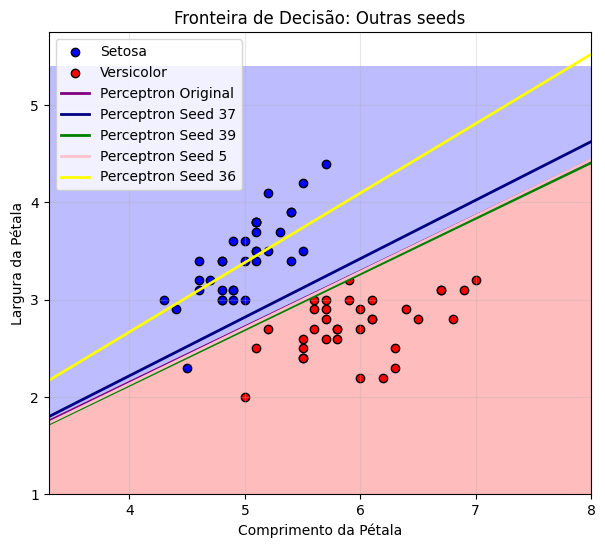

In [ ]:
modelos3 = [
    (model, 'purple', 'Perceptron Original'),
    (lista_modelos[0], 'navy', f'Perceptron Seed {seeds[0]}'),
    (lista_modelos[1], 'green', f'Perceptron Seed {seeds[1]}'),
    (lista_modelos[2], 'pink', f'Perceptron Seed {seeds[2]}'),
    (lista_modelos[3], 'yellow', f'Perceptron Seed {seeds[3]}')]

comparar_perceptron(modelos3, X_train, y_train, model, titulo="Fronteira de Decisão: Outras seeds")

Com esse experimento é visível que a seed é capaz de mudar significativante a reta encontrada pelo Perceptron, comprovando de outra forma o quão instável o modelo é dependente de parâmetros. A seed, nesse caso, foi usada para embaralhar de forma efetiva o conjunto de treinamento usado para treinar cada variação do modelo. Isso acontece porque o Perceptron é um modelo de Aprendizado Online, ou seja, os pesos são ajustados conforme as instâncias são recebidas.

Por fim, as variações da fronteira de decisão comprovam que a escolha final do Perceptron não é a melhor, e sim, uma boa.

# Teste 4: Outliers

*Usando o dataset Iris Dataset, vou testar a limitação do Perceptron em relação aos outliers. Primeiro, vou testar apenas uma classe com outliers e, em seguida, ambas as classes com outliers. O objetivo é observar se existe uma diferença significativa entre esses dois exemplos, e se na presença de duas classes com outliers pode ocorrer um equilíbrio parcial na influência desses pontos sobre a fronteira de decisão.*

# Teste 4.1: Outliers em uma classe

In [ ]:
outliers_X = np.array([
  [7.5, 2.5],
    [8.0, 3.0],
    [7.8, 2.8],
    [8.5, 3.5],
    [9.0, 3.8],
    [8.7, 2.9],
    [9.2, 4.0],
    [8.9, 3.2]
])

#classe oposta
outliers_y = np.zeros(len(outliers_X), dtype=int)

#add aos dados originais
X = np.vstack([X, outliers_X])
y = np.hstack([y, outliers_y])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
model = Perceptron(
    max_iter=1000,
    eta0=1.0,
    random_state=42,
    shuffle=True
)

In [ ]:
model.fit(X_train, y_train)

Perceptron(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

# Avaliação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, digits=4))


Relatório de Classificação:
              precision    recall  f1-score   support

           0     1.0000    0.1667    0.2857        18
           1     0.5000    1.0000    0.6667        15

    accuracy                         0.5455        33
   macro avg     0.7500    0.5833    0.4762        33
weighted avg     0.7727    0.5455    0.4589        33



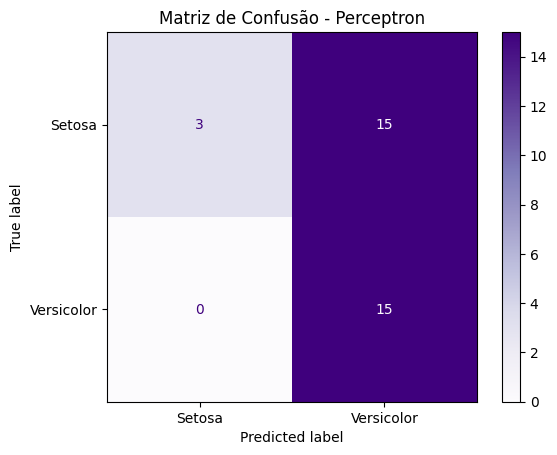

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Setosa", "Versicolor"]
)

disp.plot(cmap='Purples')

plt.title("Matriz de Confusão - Perceptron")
plt.show()

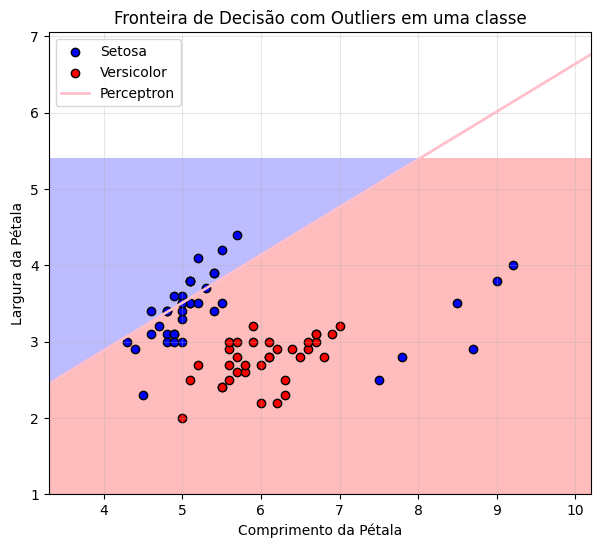

In [ ]:
modelos4 = [(model, 'pink', 'Perceptron')]
comparar_perceptron(modelos4, X_train, y_train, model, titulo="Fronteira de Decisão com Outliers em uma classe")

*A acurácia atingiu um valor intermediário. O valor do recall para a classe com outliers foi baixo e a precisão muito alta, indicando que o modelo realizou poucas previsões para essa classe, mas as previsões feitas estavam corretas. A matriz de confusão mostra que apenas 3 exemplos da classe com outliers foram classificados corretamente, enquanto todos os exemplos da outra classe foram acertados. A fronteira de decisão mostrou a reta rotacionando no sentido anti-horário em relação à fronteira de quando não havia outliers.*

#Teste 4.2: Outliers em duas classes

In [ ]:
# Inserindo outros outliers
outliers_classe0 = np.array([
    [7.5, 2.5],
    [8.0, 3.0],
    [7.8, 2.8],
    [8.5, 3.5]
])

labels_classe0 = np.zeros(len(outliers_classe0), dtype=int)

outliers_classe1 = np.array([
    [7.5, 6.5],
    [6.5, 6.1],
    [6.8,5.5],
    [7.9, 6.1]
])

labels_classe1 = np.ones(len(outliers_classe1), dtype=int)

# Junta os outliers
outliers_X = np.vstack([outliers_classe0, outliers_classe1])

# Junta os rótulos
outliers_y = np.hstack([labels_classe0, labels_classe1])

# Adiciona aos dados originais
X = np.vstack([X, outliers_X])
y = np.hstack([y, outliers_y])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
# Novo modelo
model = Perceptron(
    max_iter=1000,
    eta0=1.0,
    random_state=42,
    shuffle=True)

model.fit(X_train, y_train)

# Treinamento
y_pred = model.predict(X_test)

In [ ]:
# Avaliação
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred, digits=4))


Relatório de Classificação:
              precision    recall  f1-score   support

           0     0.5926    0.8421    0.6957        19
           1     0.6250    0.3125    0.4167        16

    accuracy                         0.6000        35
   macro avg     0.6088    0.5773    0.5562        35
weighted avg     0.6074    0.6000    0.5681        35



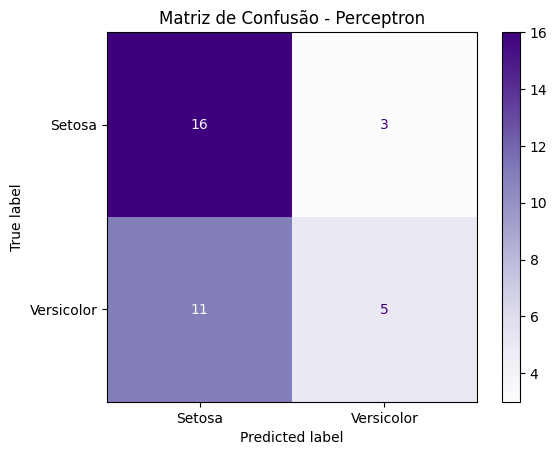

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Setosa", "Versicolor"])

disp.plot(cmap='Purples')

plt.title("Matriz de Confusão - Perceptron")
plt.show()

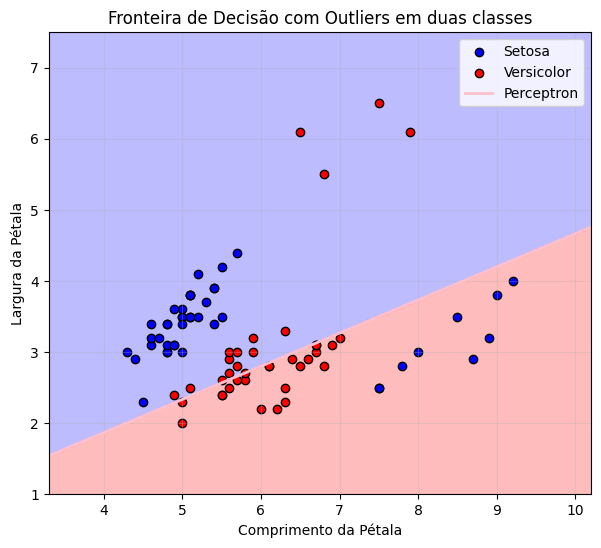

In [ ]:
modelos5 = [(model, 'pink', 'Perceptron')]
comparar_perceptron(modelos5, X_train, y_train, model, titulo="Fronteira de Decisão com Outliers em duas classes")

*A acurácia atingiu um pouco mais que a metade. A precisão para as duas classes ficou quase balanceada, mas há uma diferença significativa entre o recall da classe 0  e o da classe 1, indicando que o perceptron conseguiu identificar melhor exemplos da classe 0. A matriz de confusão mostra que 16 exemplos da classe 0 foram classificados corretamente e 3 incorretamente, enquanto, na classe 1, apenas 5 exemplos foram classificados corretamente e 11 incorretamente. A fronteira de decisão mostrou uma reta que girou no sentido horário em relação à reta do experimento com apenas uma classe contendo outliers. Sendo assim, observa-se que, nesse exemplo, a presença de outliers em ambas as classes fez com que a fronteira de decisão sofresse influência dos dois lados, embora sem sucesso na obtenção de uma separação eficiente entre as classes.*